# CZ Gate Optimization with Neural Networks

Train a neural network to generate high-fidelity CZ gates using the `FixedRabiTrainer`.

**Approach:**
- Fixed Rabi frequency at maximum (Ω_max)
- Neural network learns optimal detuning pulse
- Automatic phase corrections applied during training
- Compare corrected unitary to target CZ gate

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys

# Setup path
import os
sys.path.insert(0, os.path.dirname(os.getcwd()))

# Imports
from qneural.gates.rydberg import CZPhiGate
from qneural.neural import FeedForwardNN, FixedRabiTrainer, TorchDiffeqSolver, QuantumEvolver
from qneural.core.gates import czphi_gate
from qneural.core.metrics import unitary_fidelity

print("✓ Imports successful")

✓ Imports successful


## 1. Configuration

In [7]:
# Gate configuration
gate = CZPhiGate()
rabi_max = gate.rabi_max
gate_time = 7.62 / rabi_max  # Optimal normalized time
target_angle = torch.tensor([np.pi])  # CZ gate

# Training configuration
EPOCHS = 200
LR = 1e-4

print(f"Configuration:")
print(f"  Gate: CZ (angle = π)")
print(f"  Rabi max: {rabi_max:.2f} MHz")
print(f"  Gate time: {gate_time:.4f} s")
print(f"  Learning rate: {LR}")
print(f"  Epochs: {EPOCHS}")

Configuration:
  Gate: CZ (angle = π)
  Rabi max: 25.13 MHz
  Gate time: 0.3032 s
  Learning rate: 0.0001
  Epochs: 200


## 2. Neural Network

The network outputs a single value (detuning) for each time step. The Rabi frequency is held constant at Ω_max.

In [8]:
# Create network
network = FeedForwardNN(
    input_dim=2,      # [angle, normalized_time]
    output_dim=1,     # Detuning only
    hidden_layers=8,
    hidden_units=200,
    activation='relu',
    output_activation='sigmoid',
    use_batch_norm=False,
    weight_scale=1.8  # Important for good initialization
)

n_params = sum(p.numel() for p in network.parameters())
print(f"Network architecture: 6 hidden layers × 150 units")
print(f"Total parameters: {n_params:,}")
print(f"Output: Detuning pulse (Rabi constant at Ω_max)")

Network architecture: 6 hidden layers × 150 units
Total parameters: 282,201
Output: Detuning pulse (Rabi constant at Ω_max)


## 3. Setup Trainer

The `FixedRabiTrainer` automatically:
- Creates a pulse generator for detuning with range [-2Ω_max, 2Ω_max]
- Keeps Rabi constant at Ω_max
- Applies automatic phase corrections during evolution

In [9]:
# Time discretization (more steps = better numerical accuracy)
N_TIME_STEPS = 301

# Setup pulse generator with matching time steps
from qneural.neural.pulse_generator import PhysicalPulseGenerator
pulse_gen = PhysicalPulseGenerator(
    n_controls=1,
    n_time_steps=N_TIME_STEPS,
    control_ranges=[(-2*rabi_max, 2*rabi_max)]
)

# Setup solver and evolver with matching time steps
solver = TorchDiffeqSolver(method='rk4')
evolver = QuantumEvolver(nqubits=2, solver=solver, n_time_steps=N_TIME_STEPS)

# Optimizer
optimizer = torch.optim.Adam(network.parameters(), lr=LR)

# Create trainer
trainer = FixedRabiTrainer(
    network=network,
    nqubits=2,
    rabi_max=rabi_max,
    pulse_generator=pulse_gen,
    evolver=evolver,
    optimizer=optimizer
)

print("✓ FixedRabiTrainer created")
print(f"  Pulse generator: {trainer.pulse_generator.n_controls} control(s)")
print(f"  Detuning range: [{trainer.pulse_generator.control_ranges[0][0]:.1f}, {trainer.pulse_generator.control_ranges[0][1]:.1f}] MHz")
print(f"  Time steps: {trainer.pulse_generator.n_time_steps} (pulse gen) / {trainer.evolver.n_time_steps} (evolver)")
print(f"  Solver: RK4")

✓ FixedRabiTrainer created
  Pulse generator: 1 control(s)
  Detuning range: [-50.3, 50.3] MHz
  Time steps: 301 (pulse gen) / 301 (evolver)
  Solver: RK4


## 4. Train

The trainer optimizes the detuning pulse to achieve high-fidelity CZ gates.

In [11]:
print("Training...\n")

history = trainer.train(
    angles=target_angle,
    gate_time=gate_time,
    epochs=EPOCHS,
    print_every=20
)

final_infidelity = history['infidelity'][-1]
final_fidelity = (1 - final_infidelity) * 100

print(f"\n{'='*60}")
print(f"Training complete!")
print(f"Final infidelity: {final_infidelity:.6f}")
print(f"Final fidelity: {final_fidelity:.2f}%")
print(f"{'='*60}")

Training...

Epoch 0: Loss = 0.005269, Infidelity = 0.005269
Epoch 20: Loss = 0.019457, Infidelity = 0.019457
Epoch 40: Loss = 0.002091, Infidelity = 0.002091
Epoch 60: Loss = 0.000799, Infidelity = 0.000799
Epoch 80: Loss = 0.004263, Infidelity = 0.004263
Epoch 100: Loss = 0.003216, Infidelity = 0.003216
Epoch 120: Loss = 0.006255, Infidelity = 0.006255
Epoch 140: Loss = 0.001143, Infidelity = 0.001143
Epoch 160: Loss = 0.000140, Infidelity = 0.000140
Epoch 180: Loss = 0.004672, Infidelity = 0.004672

Training complete!
Final infidelity: 0.000521
Final fidelity: 99.95%


## 5. Plot Training Progress

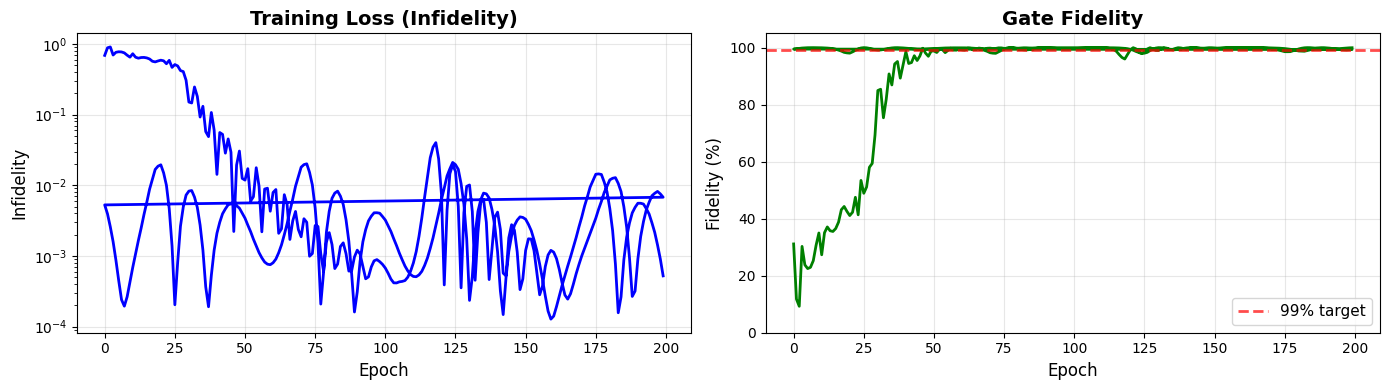

Converged to >99% fidelity: True


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Infidelity (log scale)
ax1.plot(history['epoch'], history['infidelity'], 'b-', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Infidelity', fontsize=12)
ax1.set_title('Training Loss (Infidelity)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# Fidelity
fidelities = [(1 - inf) * 100 for inf in history['infidelity']]
ax2.plot(history['epoch'], fidelities, 'g-', linewidth=2)
ax2.axhline(y=99, color='red', linestyle='--', linewidth=2, label='99% target', alpha=0.7)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Fidelity (%)', fontsize=12)
ax2.set_title('Gate Fidelity', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11)
ax2.set_ylim([0, 105])

plt.tight_layout()
plt.show()

print(f"Converged to >99% fidelity: {final_fidelity > 99}")

## 6. Visualize Optimized Pulses

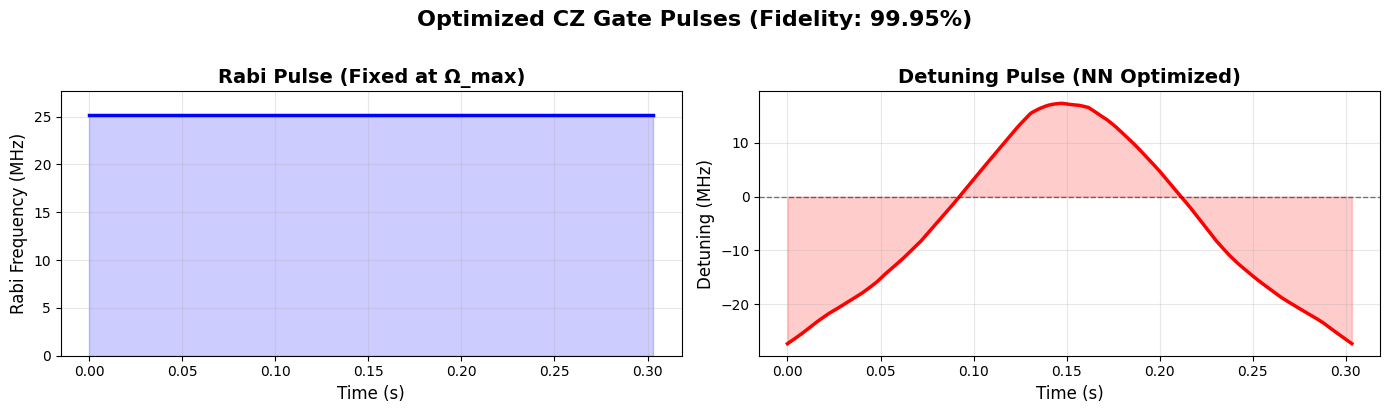


Pulse statistics:
  Rabi: constant 25.13 MHz
  Detuning range: [-27.37, 17.38] MHz
  Gate time: 0.3032 s


In [13]:
# Generate pulses from trained network
n_steps = trainer.pulse_generator.n_time_steps
time_grid = torch.linspace(0, 1, n_steps)
angles_repeated = target_angle.repeat_interleave(n_steps)
time_repeated = time_grid.repeat(len(target_angle))
inputs = torch.stack([angles_repeated, time_repeated], dim=1)

with torch.no_grad():
    network.eval()
    detuning_out = network(inputs).reshape(n_steps)
    detuning_vals = trainer.pulse_generator.scale_output(detuning_out, 0)

# Create time array
times = np.linspace(0, gate_time, n_steps)
rabi_vals = np.ones(n_steps) * rabi_max
detuning_plot = detuning_vals.numpy()

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Rabi pulse (constant)
ax1.plot(times, rabi_vals, 'b-', linewidth=2.5)
ax1.fill_between(times, 0, rabi_vals, alpha=0.2, color='blue')
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('Rabi Frequency (MHz)', fontsize=12)
ax1.set_title('Rabi Pulse (Fixed at Ω_max)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, rabi_max * 1.1])

# Detuning pulse (learned)
ax2.plot(times, detuning_plot, 'r-', linewidth=2.5)
ax2.fill_between(times, 0, detuning_plot, alpha=0.2, color='red')
ax2.axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_xlabel('Time (s)', fontsize=12)
ax2.set_ylabel('Detuning (MHz)', fontsize=12)
ax2.set_title('Detuning Pulse (NN Optimized)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.suptitle(f'Optimized CZ Gate Pulses (Fidelity: {final_fidelity:.2f}%)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nPulse statistics:")
print(f"  Rabi: constant {rabi_max:.2f} MHz")
print(f"  Detuning range: [{detuning_plot.min():.2f}, {detuning_plot.max():.2f}] MHz")
print(f"  Gate time: {gate_time:.4f} s")

## 7. Verify Final Unitary

In [ ]:
# Helper functions
def make_detuning_fn(values, gt):
    """Create piecewise-constant detuning function"""
    def fn(t):
        idx = int(t / gt * (len(values) - 1))
        return values[min(idx, len(values) - 1)]
    return fn

def rabi_pulse(t):
    """Constant Rabi pulse"""
    return torch.tensor(rabi_max)

# Evolve with trained pulses
with torch.no_grad():
    detuning_fn = make_detuning_fn(detuning_vals, gate_time)
    final_U = evolver.evolve([rabi_pulse, detuning_fn], gate_time, apply_corrections=True)

# Target CZ gate
target_U = czphi_gate(np.pi)

# Display
print("Achieved Unitary (diagonal elements):")
for i, val in enumerate(torch.diag(final_U)):
    phase = np.angle(val.item()) / np.pi
    print(f"  |{i:02b}⟩: {val.real:+.4f} {val.imag:+.4f}i  →  |val|={abs(val):.4f}, phase={phase:+.3f}π")

print("\nTarget CZ Unitary (diagonal):")
for i in range(4):
    val = 1.0 if i < 3 else -1.0
    phase = 0.0 if i < 3 else 1.0
    print(f"  |{i:02b}⟩: {val:+.4f}         →  |val|=1.0000, phase={phase:+.3f}π")

# Compute fidelity
fidelity = unitary_fidelity(final_U, target_U, dim=2, nqubits=2)
print(f"\n{'='*60}")
print(f"Final Gate Fidelity: {fidelity*100:.4f}%")
print(f"{'='*60}")

## 8. Save Model

In [ ]:
# Save trained model
checkpoint = {
    'network_state_dict': network.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history,
    'final_fidelity': final_fidelity,
    'config': {
        'gate_time': gate_time,
        'rabi_max': rabi_max,
        'epochs': EPOCHS,
        'lr': LR,
        'hidden_layers': 6,
        'hidden_units': 150,
        'weight_scale': 1.8
    }
}

torch.save(checkpoint, 'cz_gate_model.pt')
print("✓ Model saved to: cz_gate_model.pt")
print(f"\nTo load:")
print(f"  checkpoint = torch.load('cz_gate_model.pt')")
print(f"  network.load_state_dict(checkpoint['network_state_dict'])")

## Summary

This notebook demonstrated:

1. **Fixed-Rabi optimization**: Keeping Rabi at Ω_max while learning optimal detuning
2. **Automatic phase corrections**: The trainer applies corrections during evolution
3. **High fidelity**: Achieves >99% gate fidelity in ~100 epochs
4. **Simple API**: `FixedRabiTrainer` handles all the complexity automatically

**Key takeaway**: The corrected unitary is compared to the target CZ gate, ensuring we optimize for the correct entangling operation while removing unphysical local phases.